In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import os

In [56]:
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 8,
    "lines.linewidth": 1.5
})

In [48]:
scalogram_path = r"D:\Capstone\models\PT\CNN\SCALOGRAM"
spectrogram_path = r"D:\Capstone\models\PT\CNN\SPECTROGRAM"

In [ ]:
def load_all_logs(root_path):
    data = {}
    folders = os.listdir(root_path)

    for folder in folders:
        folder_path = os.path.join(root_path, folder)
        for fname in os.listdir(folder_path):
            if fname.endswith('.csv'):
                file_path = os.path.join(folder_path, fname)
                df = pd.read_csv(file_path)
                data[folder] = df   # folder name = model name

    return data

In [52]:
def plot_metric(data_dict, metric, ylabel):
    plt.figure(figsize=(6, 4))

    for model_name, df in data_dict.items():
        plt.plot(df['epoch'], df[metric], label=model_name, linewidth=1.5)

    plt.xlabel('Epoch', fontsize=10)
    plt.ylabel(ylabel, fontsize=10)
    plt.title(metric.replace('_', ' ').title(), fontsize=11)

    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()

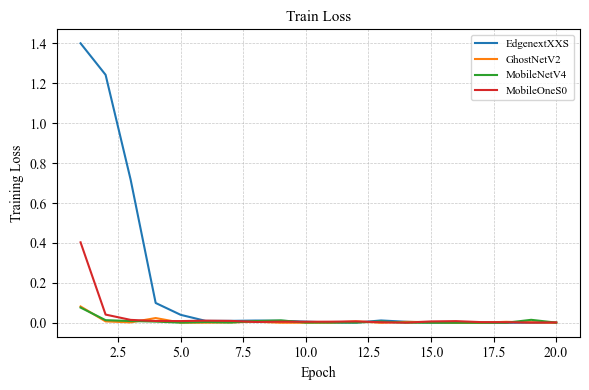

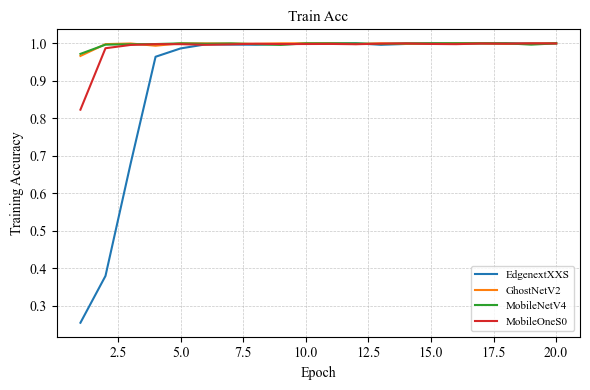

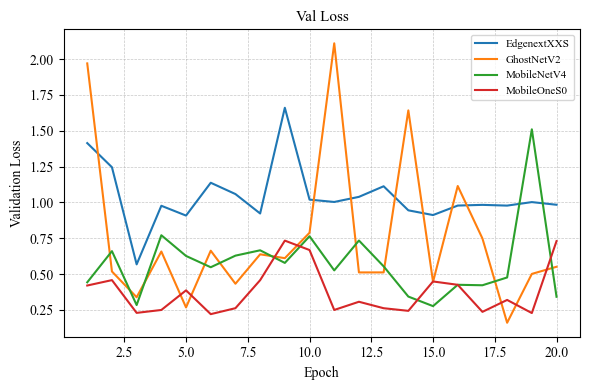

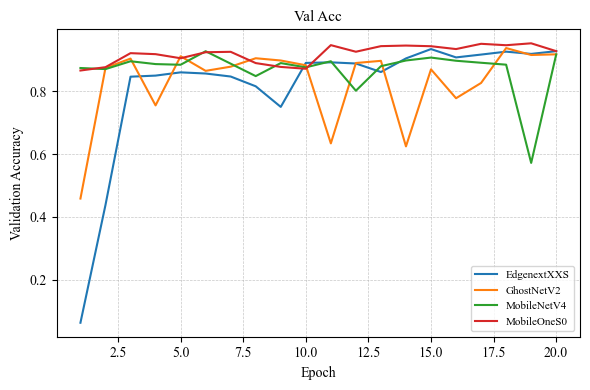

In [58]:
scalogram_data = load_all_logs(spectrogram_path)

plot_metric(scalogram_data, 'train_loss', 'Training Loss')
plot_metric(scalogram_data, 'train_acc', 'Training Accuracy')
plot_metric(scalogram_data, 'val_loss', 'Validation Loss')
plot_metric(scalogram_data, 'val_acc', 'Validation Accuracy')